Installing: git+https://github.com/facebookresearch/segment-anything.git
Installing: opencv-python-headless
Installing: scikit-image
Installing: scikit-learn
Loading SAM on cpu  (may take a moment)...
SAM ready.
Upload your image now (use file picker)...


Saving dress.jpeg to dress (5).jpeg


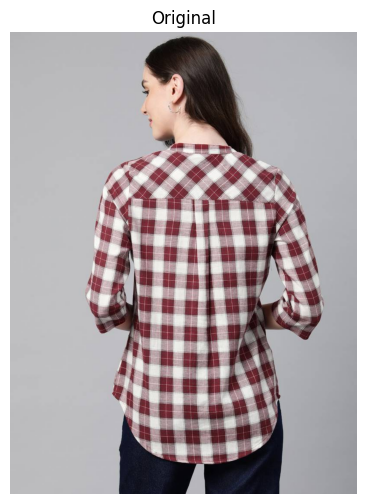

Chosen mask - area: 374742, mean_chroma: 12.36, center_score: 0.93


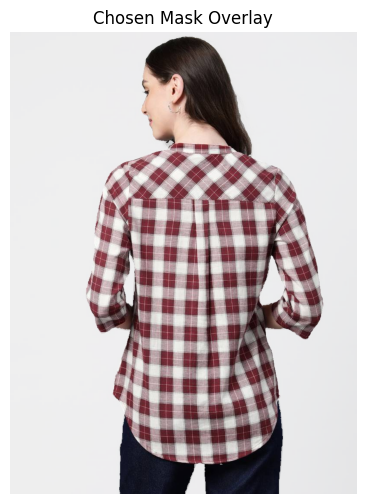

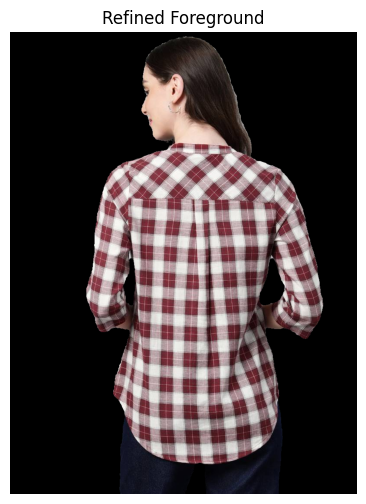

Pixels used for clustering: 143670 (chroma_th=12.00)
MeanShift succeeded with quantile=0.18, centers=4
✅ Done
Primary Colours (RGB): [(104, 46, 54), (173, 138, 142), (136, 94, 99)]
Proportions: [0.57481033 0.17064801 0.14813113]
Features: {'mean_deltaE': 21.28806775736069, 'max_deltaE': 32.36966069476944, 'min_deltaE': 14.95596658366272, 'mean_contrast': 2.335698662420865, 'max_contrast': 3.3467371297512463, 'min_contrast': 1.7770794128498195}


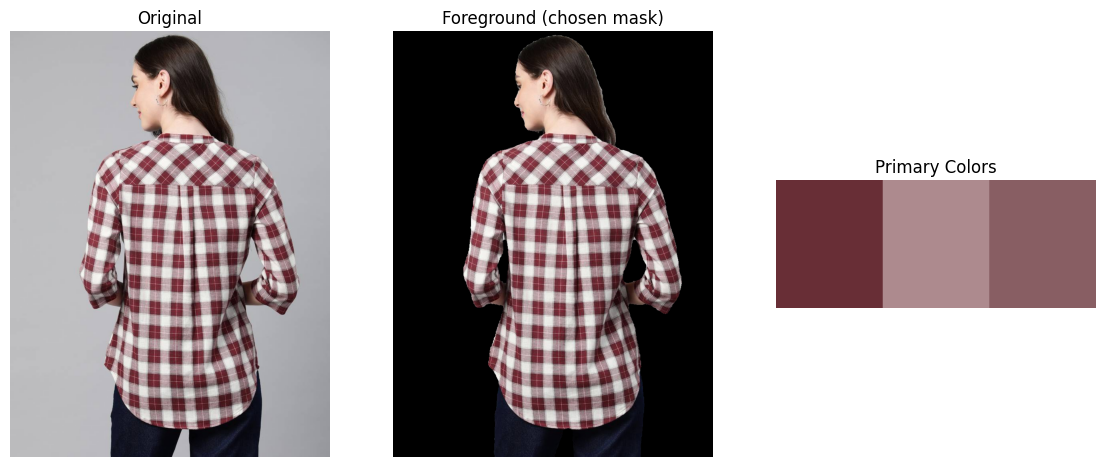

Saved: /content/segmented_foreground.png /content/contour_highlight.png


In [ ]:


# ---------------------------
# 0) Install (if needed)
# ---------------------------
import importlib, subprocess, sys
def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

required = [
    "git+https://github.com/facebookresearch/segment-anything.git",
    "colormath",
    "opencv-python-headless",
    "scikit-image",
    "scikit-learn",
    "torch",
    "torchvision",
    "matplotlib",
    "gdown"
]
for req in required:
    short = req.split("==")[0].split("+")[-1].split("/")[-1]
    try:
        importlib.import_module(short)
    except Exception:
        print("Installing:", req)
        pip_install(req)

# ---------------------------
# 1) Patch numpy.asscalar
# ---------------------------
import numpy as np
if not hasattr(np, "asscalar"):
    np.asscalar = lambda a: a.item()

# ---------------------------
# 2) Imports
# ---------------------------
import os, math, cv2
import torch
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.cluster import MeanShift, estimate_bandwidth, KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from skimage.morphology import remove_small_objects
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from colormath.color_objects import LabColor, sRGBColor
from colormath.color_conversions import convert_color
from colormath.color_diff import delta_e_cie2000
from google.colab import files

# ---------------------------
# 3) Download SAM checkpoint if missing
# ---------------------------
CKPT_NAME = "sam_vit_b.pth"
CKPT_URL  = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
if not os.path.exists(CKPT_NAME):
    print("Downloading SAM checkpoint (vit_b)...")
    !wget -q --show-progress -O {CKPT_NAME} {CKPT_URL}
    print("Done.")

if not os.path.exists(CKPT_NAME):
    raise FileNotFoundError("SAM checkpoint missing. Re-run the cell.")

# ---------------------------
# 4) Load SAM robustly
# ---------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Loading SAM on", DEVICE, " (may take a moment)...")
sam = sam_model_registry["vit_b"](checkpoint=None)
try:
    state = torch.load(CKPT_NAME, map_location=DEVICE, weights_only=False)
    sam.load_state_dict(state)
except TypeError:
    # older torch doesn't accept weights_only kw; try without it
    state = torch.load(CKPT_NAME, map_location=DEVICE)
    sam.load_state_dict(state)
sam.to(DEVICE)
sam.eval()
mask_generator = SamAutomaticMaskGenerator(sam)
print("SAM ready.")

# ---------------------------
# 5) Upload image
# ---------------------------
print("Upload your image now (use file picker)...")
uploaded = files.upload()
if not uploaded:
    raise RuntimeError("No file uploaded.")
image_path = list(uploaded.keys())[0]

bgr = cv2.imread(image_path)
if bgr is None:
    raise FileNotFoundError(f"Could not read uploaded file: {image_path}")
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
H, W = rgb.shape[:2]

plt.figure(figsize=(6,6))
plt.imshow(rgb); plt.title("Original"); plt.axis("off"); plt.show()

# ---------------------------
# 6) Generate masks and score them
# ---------------------------
masks = mask_generator.generate(rgb)
if not masks:
    raise RuntimeError("SAM returned no masks.")

# compute metrics for top-k masks by area
masks_sorted_by_area = sorted(masks, key=lambda m: m.get("area",0), reverse=True)
top_k = min(8, len(masks_sorted_by_area))
candidates = masks_sorted_by_area[:top_k]

# Precompute lab image for chroma calculations
img_lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)  # OpenCV L in 0..255, a,b in 0..255 (128 offset)
cent_x, cent_y = W/2.0, H/2.0

mask_infos = []
max_area = 0
max_chroma = 0.0
for m in candidates:
    seg = m['segmentation'].astype(bool)
    area = int(seg.sum())
    if area == 0:
        continue
    max_area = max(max_area, area)
    # mean chroma for that mask:
    lab_pixels = img_lab[seg]
    # convert a,b to centered (-128..127)
    a = lab_pixels[:,1].astype(float) - 128.0
    b = lab_pixels[:,2].astype(float) - 128.0
    mean_chroma = float(np.mean(np.sqrt(a**2 + b**2)))
    max_chroma = max(max_chroma, mean_chroma)
    # center score
    ys, xs = np.where(seg)
    cx, cy = float(xs.mean()), float(ys.mean())
    dx = (cx - cent_x) / W
    dy = (cy - cent_y) / H
    dist = math.sqrt(dx*dx + dy*dy)  # normalized
    center_score = 1.0 - min(dist, 1.0)  # closer to center -> higher
    mask_infos.append({
        'seg': seg,
        'area': area,
        'mean_chroma': mean_chroma,
        'center_score': center_score,
        'raw': m
    })

# normalize and compute final score (weights chosen to prefer colorful, large, central masks)
if not mask_infos:
    raise RuntimeError("No candidate masks to evaluate.")

for info in mask_infos:
    norm_area = info['area'] / (max_area + 1e-9)
    norm_chroma = info['mean_chroma'] / (max_chroma + 1e-9)
    # weights: area (0.45), chroma (0.45), center (0.1)
    score = 0.45*norm_area + 0.45*norm_chroma + 0.10*info['center_score']
    info['score'] = score

# pick the mask with highest score
best = max(mask_infos, key=lambda x: x['score'])
mask_bool = best['seg']
print(f"Chosen mask - area: {best['area']}, mean_chroma: {best['mean_chroma']:.2f}, center_score: {best['center_score']:.2f}")

# visualize chosen mask overlay
mask_uint8 = (mask_bool.astype("uint8") * 255)
overlay = rgb.copy()
overlay[mask_uint8==0] = (overlay[mask_uint8==0]*0.25 + 255*0.75).astype(np.uint8)  # dim background
plt.figure(figsize=(6,6)); plt.imshow(overlay); plt.title("Chosen Mask Overlay"); plt.axis("off"); plt.show()

# ---------------------------
# 7) Clean & refine mask
# ---------------------------
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9))
mask_uint8 = cv2.morphologyEx(mask_uint8, cv2.MORPH_CLOSE, kernel, iterations=1)
mask_bool2 = mask_uint8.astype(bool)
mask_bool2 = remove_small_objects(mask_bool2, min_size=int(0.001 * H * W))  # drop tiny specks
strong_mask = (mask_bool2.astype("uint8") * 255)
foreground = cv2.bitwise_and(rgb, rgb, mask=strong_mask)

plt.figure(figsize=(6,6)); plt.imshow(foreground); plt.title("Refined Foreground"); plt.axis("off"); plt.show()
cv2.imwrite("/content/segmented_foreground.png", cv2.cvtColor(foreground, cv2.COLOR_RGB2BGR))

# ---------------------------
# 8) Prepare pixels (OpenCV Lab) and per-pixel chroma filter (adaptive)
# ---------------------------
lab_fore = cv2.cvtColor(foreground, cv2.COLOR_RGB2LAB)
lab_pixels_all = lab_fore[mask_bool2]   # all masked pixels
if lab_pixels_all.size == 0:
    raise RuntimeError("No pixels in chosen mask after refinement.")

# brightness filter
L_vals = lab_pixels_all[:,0]
keep_mask = (L_vals > 10) & (L_vals < 245)
lab_pixels = lab_pixels_all[keep_mask]
orig_count = lab_pixels_all.shape[0]
if lab_pixels.shape[0] == 0:
    raise RuntimeError("All masked pixels filtered out by brightness threshold.")

# per-pixel chroma (a,b center-subtracted)
a_vals = lab_pixels[:,1].astype(float) - 128.0
b_vals = lab_pixels[:,2].astype(float) - 128.0
pixel_chroma = np.sqrt(a_vals*a_vals + b_vals*b_vals)

# adaptive chroma thresholding:
CHROMA_START = 12.0
chroma_th = CHROMA_START
filtered_idx = pixel_chroma >= chroma_th
# if too few pixels after chroma filter, relax chroma threshold
min_keep_ratio = 0.03
while filtered_idx.sum() < max(50, int(min_keep_ratio * orig_count)) and chroma_th > 1.0:
    chroma_th /= 2.0
    filtered_idx = pixel_chroma >= chroma_th

lab_pixels_filtered = lab_pixels[filtered_idx]
if lab_pixels_filtered.size == 0:
    # fallback to unfiltered lab_pixels
    lab_pixels_filtered = lab_pixels.copy()
    print("Warning: chroma filtering removed too many pixels — falling back to unfiltered pixels.")

print(f"Pixels used for clustering: {len(lab_pixels_filtered)} (chroma_th={chroma_th:.2f})")

# ---------------------------
# 9) Sample for clustering
# ---------------------------
MAX_SAMPLE = 3500
if len(lab_pixels_filtered) > MAX_SAMPLE:
    rng = np.random.default_rng(42)
    samp_idx = rng.choice(len(lab_pixels_filtered), size=MAX_SAMPLE, replace=False)
    lab_sample = lab_pixels_filtered[samp_idx].astype(float)
else:
    lab_sample = lab_pixels_filtered.astype(float)

# ---------------------------
# 10) MeanShift clustering (Lab-space)
# ---------------------------
def try_meanshift(sample, quantiles=(0.18,0.28,0.12,0.08)):
    for q in quantiles:
        try:
            bw = estimate_bandwidth(sample, quantile=q, n_samples=min(500, len(sample)))
            if not np.isfinite(bw) or bw <= 0:
                continue
            ms = MeanShift(bandwidth=bw, bin_seeding=True)
            ms.fit(sample)
            return ms.cluster_centers_, ms, q
        except Exception:
            continue
    return None, None, None

centers, ms_model, used_q = try_meanshift(lab_sample, quantiles=(0.18,0.28,0.12,0.06))
if centers is None:
    # fallback to KMeans small k
    K = 3
    print("MeanShift failed — falling back to KMeans(k=3)")
    km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(lab_sample)
    centers = km.cluster_centers_
    used_q = None
else:
    print(f"MeanShift succeeded with quantile={used_q}, centers={len(centers)}")

# ---------------------------
# 11) Assign all filtered pixels to nearest centers to compute proportions
# ---------------------------
all_lab = lab_pixels_filtered.astype(float)
closest_idx, _ = pairwise_distances_argmin_min(all_lab, centers)
counts = Counter(closest_idx)
total = sum(counts.values())
center_items = sorted(counts.items(), key=lambda x: -x[1])
center_indices = [ci for ci, _ in center_items]
center_counts = [cnt for _, cnt in center_items]
center_props = np.array(center_counts, dtype=float) / total

# Convert OpenCV-Lab center -> RGB and colormath LabColor
def lab_opencv_to_rgb_tuple(lab_opencv):
    lab_arr = np.uint8([[lab_opencv]])
    rgb_val = cv2.cvtColor(lab_arr, cv2.COLOR_Lab2RGB)[0,0]
    return (int(rgb_val[0]), int(rgb_val[1]), int(rgb_val[2]))

def lab_opencv_to_labcolor(lab_opencv):
    L = float(lab_opencv[0]) * 100.0 / 255.0
    a = float(lab_opencv[1]) - 128.0
    b = float(lab_opencv[2]) - 128.0
    return LabColor(L, a, b)

raw_centers = [centers[i] for i in center_indices]
swatches_rgb = [lab_opencv_to_rgb_tuple(c) for c in raw_centers]
labcolor_centers = [lab_opencv_to_labcolor(c) for c in raw_centers]

# ---------------------------
# 12) Merge visually similar centers and drop very low-chroma clusters
# ---------------------------
MERGE_DELTAE = 6.0
MIN_CHROMA_FINAL = 6.0

final_centers, final_props, final_lab = [], [], []
for labc, rgbc, prop in zip(labcolor_centers, swatches_rgb, center_props):
    chroma = math.sqrt(labc.lab_a**2 + labc.lab_b**2)
    if chroma < MIN_CHROMA_FINAL:
        # skip near-grey/white clusters
        continue
    merged = False
    for j, exist_lab in enumerate(final_lab):
        if delta_e_cie2000(labc, exist_lab) < MERGE_DELTAE:
            final_props[j] += prop
            merged = True
            break
    if not merged:
        final_lab.append(labc)
        final_centers.append(rgbc)
        final_props.append(prop)

# fallback if nothing left after filtering
if len(final_centers) == 0:
    final_centers = swatches_rgb
    final_props = center_props.tolist()
    final_lab = labcolor_centers

final_props = np.array(final_props, dtype=float)
if final_props.sum() > 0:
    final_props /= final_props.sum()

# Keep top N
TOP_N = 3
primary_colors = final_centers[:TOP_N]
proportions = final_props[:TOP_N]
lab_colors_for_features = final_lab[:TOP_N]

# ---------------------------
# 13) Compute ΔE & WCAG contrast features
# ---------------------------
def wcag_contrast(rgb1, rgb2):
    def rel_lum(rgb):
        r,g,b = [c/255.0 for c in rgb]
        def f(c): return c/12.92 if c <= 0.03928 else ((c+0.055)/1.055)**2.4
        return 0.2126*f(r) + 0.7152*f(g) + 0.0722*f(b)
    L1, L2 = rel_lum(rgb1), rel_lum(rgb2)
    return (max(L1,L2)+0.05) / (min(L1,L2)+0.05)

dEs, contrs = [], []
if len(lab_colors_for_features) >= 2:
    for i in range(len(lab_colors_for_features)):
        for j in range(i+1, len(lab_colors_for_features)):
            dEs.append(float(delta_e_cie2000(lab_colors_for_features[i], lab_colors_for_features[j])))
            contrs.append(float(wcag_contrast(primary_colors[i], primary_colors[j])))

features = {
    "mean_deltaE": float(np.mean(dEs)) if dEs else 0.0,
    "max_deltaE":  float(np.max(dEs)) if dEs else 0.0,
    "min_deltaE":  float(np.min(dEs)) if dEs else 0.0,
    "mean_contrast": float(np.mean(contrs)) if contrs else 0.0,
    "max_contrast":  float(np.max(contrs)) if contrs else 0.0,
    "min_contrast":  float(np.min(contrs)) if contrs else 0.0,
}

# ---------------------------
# 14) Output + visualizations
# ---------------------------
print("✅ Done")
print("Primary Colours (RGB):", primary_colors)
print("Proportions:", proportions)
print("Features:", features)

# save images
out_seg = "/content/segmented_foreground.png"
out_cont = "/content/contour_highlight.png"
cv2.imwrite(out_seg, cv2.cvtColor(foreground, cv2.COLOR_RGB2BGR))

contour_img = rgb.copy()
contours, _ = cv2.findContours(strong_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(contour_img, contours, -1, (255,255,0), 3)
cv2.imwrite(out_cont, cv2.cvtColor(contour_img, cv2.COLOR_RGB2BGR))

# show: original, foreground, color palette
plt.figure(figsize=(14,6))
plt.subplot(1,3,1); plt.imshow(rgb); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(foreground); plt.title("Foreground (chosen mask)"); plt.axis("off")

# palette
plt.subplot(1,3,3)
canvas = np.ones((120, 300, 3), dtype=np.uint8) * 255
n = len(primary_colors)
if n > 0:
    for i, (c, p) in enumerate(zip(primary_colors, proportions)):
        x0 = int(i * (300 / n))
        w = int(300 / n)
        canvas[:, x0:x0+w, :] = np.array(c, dtype=np.uint8)
plt.imshow(canvas); plt.title("Primary Colors"); plt.axis("off")
plt.show()

print("Saved:", out_seg, out_cont)
